**Descripción del contexto y la procedencia del dataset: qué mide, quién lo recolectó, cuándo, y cuál es la unidad de observación.**
1. Descripción: Datos del artículo *Working memory contributions to reinforcement learning impairments in schizophrenia" (Collins et al., 2014) in JoN (Journal Of Nueroscience)*
2. Acceso: OSF (Open Science Framework)
3. Date Created: Feb 22, 2023, 12:02 PM
4. Date Updated: May 8, 2023, 1:36 PM
5. Contribuidores: CCNLab UC Berkeley (https://ccn.studentorg.berkeley.edu/)
6. Enlace al artículo: https://pubmed.ncbi.nlm.nih.gov/25297101/
7. Cita: Berkeley, C. U. (2023, May 8). Data for Collins et al., 2014 JoN. Retrieved from osf.io/q67tb
8. Enlace para acceso: https://osf.io/q67tb/overview
9.  El repositorio de origen no declara una licencia explícita. Pero se cita a la fuente.
10. Breve resumen del artículo, generado por IA: El paper investiga por qué las personas con esquizofrenia muestran déficits en tareas de aprendizaje por refuerzo, proponiendo que estos no se deben principalmente a fallas en el sistema de reinforcement learning (RL), sino a alteraciones en la working memory (WM). Para ello, los autores utilizan una tarea conductual que manipula la carga de memoria (variando el número de estímulos por bloque) junto con un modelo computacional híbrido (RLWM) que separa ambos procesos. Los resultados muestran que, aunque los pacientes tienen peor desempeño global, sus parámetros de aprendizaje por refuerzo permanecen relativamente intactos; en cambio, presentan menor capacidad de memoria de trabajo, mayor olvido y menor uso de este sistema. Esto sugiere que los déficits observados en aprendizaje no son puramente dopaminérgicos o de RL, sino que emergen principalmente de limitaciones en memoria de trabajo que afectan el desempeño en estas tareas.

Datos:

| Columna | Explicación |
|---|---|
| subno | Identificador |
| block | Número de bloque |
| ns | Tamaño de conjunto |
| time | Número de eensayo |
| stimseq | ID del estímulo |
| imageseq | Número de imagen actual |
| folderseq | Número de la categoría de la imagen |
| iterseq | Número de iteración por estímulo |
| corAseq | Acción correcta |
| choice | Acción actual |
| key | Tecla presionada |
| cor | Es correcto? Sí/No -> 0/1 |
| rew | Recibió recompensa? Sí/No -> 0/1 |
| rt | Tiempo de reacción |
| condition (HC=0,SZ=1) | Condición experimental. 0: grupo control / 1: esquizofrenia. **Variable objetivo** |
| pcor | número de ensayos correctos previos para un estímulo dado (utilizado para regresión logística) |
| delay | demora desde el último ensayo correcto para el mismo estímulo |

________________________________________________________________________________

**Verificación de la estructura: dimensiones y tipo de cada atributo, incluyendo una celda inicial que compruebe el cumplimiento de los requisitos anteriores.**

In [28]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)
print("sklearn   ", sklearn.__version__)
print("imblearn  ", imblearn.__version__)

numpy      2.1.3
pandas     2.2.3
matplotlib 3.10.0
seaborn    0.13.2
sklearn    1.6.1
imblearn   0.14.2


In [29]:
# crear dataframe
df =pd.read_csv("/content/drive/MyDrive/INTRODUCCIÓN A LA CIENCIA DE DATOS/practicas/practica2/data/CollinsEtAl_2014_JoN.csv")
df

,subno,block,ns,time,stimseq,imageseq,folderseq,iterseq,corAseq,choice,key,cor,rew,rt,"condition (HC=0,SZ=1)",pcor,delay
0,3093,1,6,1,2,1,4,1,2,1,31,0,0,2.807862,1,0,NaN
1,3093,1,6,2,1,4,4,1,1,2,30,0,0,1.069457,1,0,NaN
2,3093,1,6,3,5,3,4,1,3,3,32,1,1,1.028125,1,0,NaN
3,3093,1,6,4,6,2,4,1,3,1,31,0,0,0.889233,1,0,NaN
4,3093,1,6,5,4,5,4,1,2,2,30,1,1,0.808525,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46671,82462,13,4,34,1,2,6,8,1,2,32,0,0,0.803903,0,4,4.0
46672,82462,13,4,35,1,2,6,9,1,1,31,1,1,0.421560,0,4,5.0
46673,82462,13,4,36,2,6,6,9,2,2,32,1,1,0.659719,0,6,5.0
46674,82462,13,4,37,3,5,6,10,2,2,32,1,1,0.543558,0,8,5.0


In [30]:
n_filas, n_columnas = df.shape
n_numericas = df.select_dtypes(include="number").shape[1]
n_no_numericas = df.select_dtypes(exclude="number").shape[1]

print(f"Registros:               {n_filas:>5}")
print(f"Atributos:               {n_columnas:>5}")
print(f"  numéricos:             {n_numericas:>5}")
print(f"  no numéricos:          {n_no_numericas:>5}")
print(f"Duplicados exactos:      {df.duplicated().sum():>5}")
print(f"Registros con faltantes: {df.isna().any(axis=1).sum():>5}")

Registros:               46676
Atributos:                  17
  numéricos:                17
  no numéricos:              0
Duplicados exactos:          0
Registros con faltantes: 10544


1. Se marcan 0 datos no numéricos, pero las columnas *'cor'* y *'rew'* son binarias (sí/no), por lo tanto, nominales. Solo que ya vienen procesadas en valores numéricos.
2. No se elimina la columna de ID, ya que hay varios registros para cada participante.

**Análisis de la calidad de los datos: patrón de valores faltantes, duplicados, valores imposibles, y cardinalidad de los atributos categóricos.**

FALTANTES

In [31]:
proporcion_faltantes = df.isna().mean().sort_values(ascending=False)
proporcion_faltantes = proporcion_faltantes[proporcion_faltantes > 0]

pd.DataFrame({
    "faltantes": df.isna().sum()[proporcion_faltantes.index],
    "porcentaje": (proporcion_faltantes * 100).round(1),
})

,faltantes,porcentaje
delay,10544,22.6


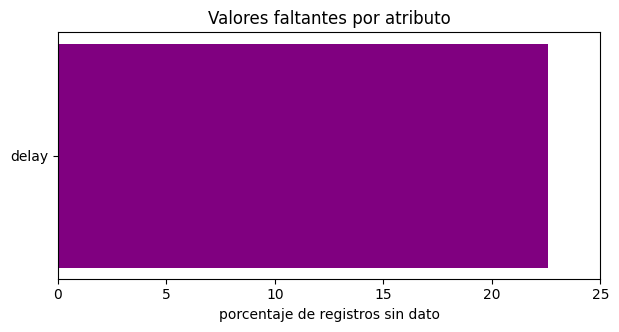

In [32]:
fig, ax = plt.subplots(figsize=(7, 3.2))

ax.barh(proporcion_faltantes.index[::-1],
        proporcion_faltantes.values[::-1] * 100, color="purple")

ax.set_xlabel("porcentaje de registros sin dato")
ax.set_title("Valores faltantes por atributo")
ax.set_xlim(0, 25)
plt.show()

**Lectura.** Solo un atributo tiene faltantes. Que es la demora desde el último ensayo correcto para el mismo estímulo. Por lo que hay que analizar si estos faltantes siguen un patrón.

Verificar si los faltantes en delay son sistemáticos. Ya sea que falta delay por participante, por tamaño de conjunto, por bloque o por estímulo.

In [33]:
columnas = ["subno", "ns", "block", "stimseq"]
faltantes = {}
for columna in columnas:
    faltantes_bloque = (
        df.groupby(columna)["delay"]
        .agg(lotes="size", sin_faltantes=lambda valores: valores.isna().mean())
        .query("lotes >= 30")
        .sort_values("sin_faltantes", ascending=False)
    )
    faltantes[columna] = faltantes_bloque

Primero verificar en tamaño de conjunto, bloque o estímulo. Ya que tienen un número pequeño y se puede visualizar.

In [34]:
print ((faltantes["ns"]["sin_faltantes"] * 100).round(1))
print ((faltantes["block"]["sin_faltantes"] * 100).round(1))
print ((faltantes["stimseq"]["sin_faltantes"] * 100).round(1))

ns
4    23.9
5    23.8
6    22.1
3    22.0
2    20.0
Name: sin_faltantes, dtype: float64
block
1     23.8
3     23.6
2     23.6
12    23.2
8     23.1
11    23.0
9     23.0
13    22.7
6     22.4
10    22.1
7     22.1
4     20.7
5     19.8
Name: sin_faltantes, dtype: float64
stimseq
4    24.3
6    23.8
3    23.4
5    23.1
2    21.8
1    21.4
Name: sin_faltantes, dtype: float64


Luego verificar en participantes. Ya que tienen un número grande y es difícil visualizar, por eso se pide que se muestren aquellos mayores a 30%

In [35]:
faltantes["subno"][faltantes["subno"]["sin_faltantes"] > 0.30]

,lotes,sin_faltantes
subno,,


Los faltantes se distribuyen de maner similar en todas las variables analizadas. Esto sugiere que los faltantes no son sistemáticos. No se encuentra un patrón específico.

DUPLICADOS

In [36]:
print("Duplicados exactos:", df.duplicated().sum())
print("Duplicados en los atributos de unidad experimental:",
      df.duplicated(subset=["ns", "block", "time"]).sum())

Duplicados exactos: 0
Duplicados en los atributos de unidad experimental: 43445


**Lectura.** No hay duplicados exactos. Sí hay muchas filas que comparten los atributos de unidad experimental. Esto es esperado, ya que las tareas experimentales implementadas en el artículo son repetitivas.

VALORES IMPOSIBLES Y FUERA DE RANGO

In [37]:
df.describe().round(1)

,subno,block,ns,time,stimseq,imageseq,folderseq,iterseq,corAseq,choice,key,cor,rew,rt,"condition (HC=0,SZ=1)",pcor,delay
count,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,36132.0
mean,60432.6,7.2,4.4,27.2,2.7,3.5,10.6,6.4,2.0,2.0,30.8,0.7,0.7,0.8,0.6,3.4,5.9
std,23476.0,3.6,1.4,20.2,1.5,1.7,5.2,3.8,0.8,0.8,2.1,0.4,0.4,0.4,0.5,3.1,6.2
min,3093.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,1.0
25%,56507.0,4.0,3.0,11.0,1.0,2.0,6.0,3.0,1.0,1.0,30.0,0.0,0.0,0.6,0.0,1.0,2.0
50%,69355.0,8.0,5.0,23.0,2.0,3.0,10.0,6.0,2.0,2.0,31.0,1.0,1.0,0.7,1.0,3.0,4.0
75%,80695.0,10.0,6.0,40.0,4.0,5.0,15.0,9.0,3.0,3.0,32.0,1.0,1.0,1.0,1.0,5.0,8.0
max,82462.0,13.0,6.0,90.0,6.0,6.0,19.0,15.0,3.0,3.0,32.0,1.0,1.0,3.5,1.0,14.0,84.0


Las variables 'choice', 'key', 'cor', 'rew' y 'rt', hasta donde entendí el artículo, no deberían de tener valores negativos.

In [38]:
columnas = ['choice', 'key', 'cor', 'rew', 'rt']
(df[columnas] == -1).sum()

,0
choice,181
key,181
cor,181
rew,181
rt,181


la suma de '-1' para cada columna es el mismo. Lo que sugiere que quizá es una manera de representar datos faltantes.

In [39]:
for columna in columnas:
    print(f"\n--- {columna} ---")
    print(df[columna].unique())


--- choice ---
[ 1  2  3 -1]

--- key ---
[31 30 32 -1]

--- cor ---
[ 0  1 -1]

--- rew ---
[ 0  1 -1]

--- rt ---
[2.80786205 1.06945734 1.02812543 ... 0.65971926 0.54355773 0.72818695]


Aquí se puede observar que sí es un valor predefinido para valores nulos.

CARDINALIDAD Y CODIFICACIÓN INCONSISTENTE

Como se comentó anteriormente, las columnas 'cor' y 'rew' son categoricas (binarias), pero ya estan codificadas en números (1 y 0). Ya revisamos que también tienen datos nulos, marcados como '-1'. Por lo que ya no se hace un análisis más profundo, como de frecuencia de categorías, ya que son variables binarias.

**DESICIONES DE LIMPIEZA.**
1. Los datos, de alguna manera, son series de tiempo. Ya que son secuencias, ensayo a ensayo, de tareas experimentales. Por lo tanto, eliminar los nulos de 'delay' podría afectar. Además, en esa columna un dato nulo no significa que no hubo delay, quizá solo el delay fue tan pequeño que la máquina no lo registró. Por lo tanto, convertir los NaN a 0 es mejor opción.


In [40]:
df["delay"] = df["delay"].fillna(0)
print(df["delay"].isna().sum())

0


2. Los 181 datos marcados con -1 sí son un problema, porque implican falta de respuesta o un mal registro. Por lo tanto, estos sí se eliminan.

In [41]:
df = df[df["choice"] != -1]

In [42]:
columnas = ['choice', 'key', 'cor', 'rew', 'rt']
(df[columnas] == -1).sum()

,0
choice,0
key,0
cor,0
rew,0
rt,0


Antes de continuar con los análisis, hacemos una breve inspección

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46495 entries, 0 to 46675
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subno                  46495 non-null  int64  
 1   block                  46495 non-null  int64  
 2   ns                     46495 non-null  int64  
 3   time                   46495 non-null  int64  
 4   stimseq                46495 non-null  int64  
 5   imageseq               46495 non-null  int64  
 6   folderseq              46495 non-null  int64  
 7   iterseq                46495 non-null  int64  
 8   corAseq                46495 non-null  int64  
 9   choice                 46495 non-null  int64  
 10  key                    46495 non-null  int64  
 11  cor                    46495 non-null  int64  
 12  rew                    46495 non-null  int64  
 13  rt                     46495 non-null  float64
 14  condition (HC=0,SZ=1)  46495 non-null  int64  
 15  pcor   

**ANÁLISIS UNIVARIADO**: distribución y estadísticos descriptivos de los atributos relevantes.


Hasta este paso, solo las columnas 'cor' y 'rew' se habían tomado como categóricas, ya que el que las variables estén codificadas en números permitió una exploración más rápida. Sin embargo, para los siguientes análisis ya conviene realizar una separación entre variables numéricas y categóricas.

Separación de variables en categóricas y numéricas:

| Columna | Escala | Justificación |
|---|---|---|
| subno | Nominal | Los números solo identifican participantes|
| block | Ordinal| Los bloques siguen un orden, pero no representan cantidades |
| ns | Razón | Número de estímulos en el conjunto |
| time | Razón | Secuencia de ensayo |
| stimseq | Nominal | ID del estímulo |
| imageseq | Razón | Secuencia de la imagen. |
| folderseq | Nominal | ID de la categoría de imagen |
| iterseq | Ordinal | Número de iteración por estímulo, un ID |
| corAseq | Nominal | Las acciones son categorías |
| choice | Nominal | Las respuestas son categorías |
| key | Nominal | Tecla presionada. Es una categoría de respuesta, no una magnitud |
| cor | Nominal (dicotómica) | Correcto/incorrecto |
| rew | Nominal (dicotómica) | Recompensa/no recompensa |
| rt | Razón | Tiempo de reacción |
| condition (HC=0,SZ=1) | Nominal (dicotómica) | El 0/1 identifica grupos |
| pcor | Razón | Número de ensayos correctos previos para un estímulo, es un conteo con cero significativo |
| delay | Razón | Demora temporal desde el último ensayo correcto |

In [44]:
variables_numericas = ['ns', 'time', 'imageseq', 'rt', 'pcor', 'delay']
variables_categoricas = ['block', 'stimseq', 'folderseq', 'iterseq',
                         'corAseq', 'choice', 'key', 'cor', 'rew',
                         'condition (HC=0,SZ=1)']

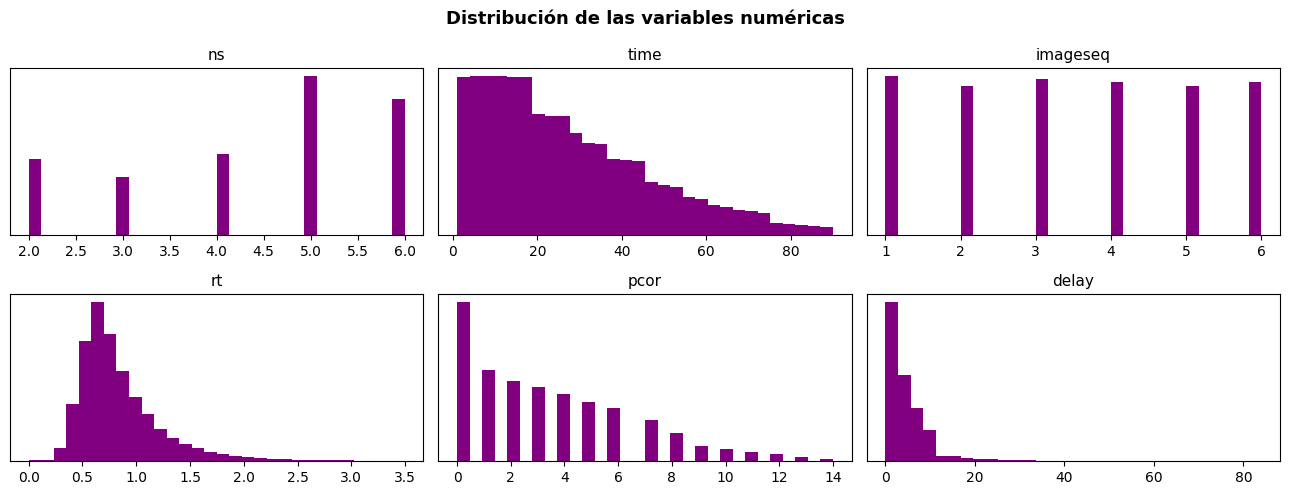

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5))

for ax, columna in zip(axes.ravel(), variables_numericas):
    ax.hist(df[columna].dropna(), bins=30, color='purple')
    ax.set_title(columna, fontsize=11)
    ax.set_yticks([])

fig.suptitle("Distribución de las variables numéricas",
             fontsize=13, color='black', fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura**: La gráfica 'ns', correspondiente al número de estímulos por conjunto (tamaño de conjunto) muestra una distribución correspondiente a sus valores predefinidos: 2,3,4,5 y 6. El 'time', que es el número de ensayo, disminuye su frecuencia conforme aumenta. Esto es consistente con que hay menor número de ensayos debido al tamaño del conjunto. La tarea experimental considera menos tamañaos de conjuntos altos. 'imageseq', la secuencia de la imagen, tiene los mismos valores predefinidos que 'ns', aunque una distribucón uniforme. El tiempo de reacción, 'rt', se sesga a la izquierda; lo que sugiere que los tiempos de reacción se distribuyen más en valores bajos. El número de ensayos correctos previos para un estímulo dado, 'pcor', también se sesga a la izquierda, pero es una variable discreta. Por último, 'delay', también se carga hacia la izquierda, entre 0-20. Esta gráfica sugiere que no pasa demasiado tiempo entre un estímulo y su acción correcta y volver a observar dicho estímulo.

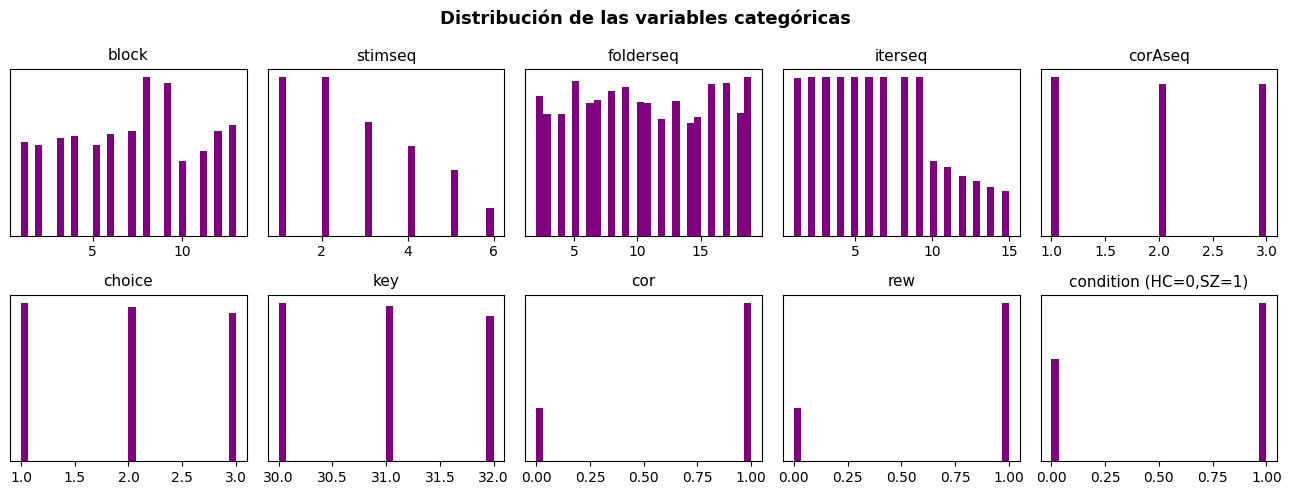

In [46]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5))

for ax, columna in zip(axes.ravel(), variables_categoricas):
    ax.hist(df[columna].dropna(), bins=30, color='purple')
    ax.set_title(columna, fontsize=11)
    ax.set_yticks([])

fig.suptitle("Distribución de las variables categóricas",
             fontsize=13, color='black', fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura**: 'choice', 'key', y 'corAseq' solo tienen 3 valores discretos predefinidos, y esto se observa en sus gráficas. Por lo tanto, son consistentes con lo reportado en el artículo. 'cor', 'rew' y 'condition (HC=0,SZ=1)' son variables dicotomicas, y tambiés esto se visualiza en su distribución. 'cor' y 'rew' deben de tener la misma distribución, ya que si hubo una respuesta correcta se entrega una recompensa. 'block' corresponde al número del bloque, por lo que su distribucón es consistente con la cantidad de bloques por tarea experimental. 'stimseq' es solo un identificador. 'folderseq' es el número de la categoría de la imagen, 'iterseq' el número de iteración por estímulo por lo tanto, ambos identificadores.

**ANÁLISIS BIVARIADO**: relaciones entre pares de atributos, justificando cuáles se exploran y por qué

¿Cómo afecta el tamaño de conjunto en el delay?


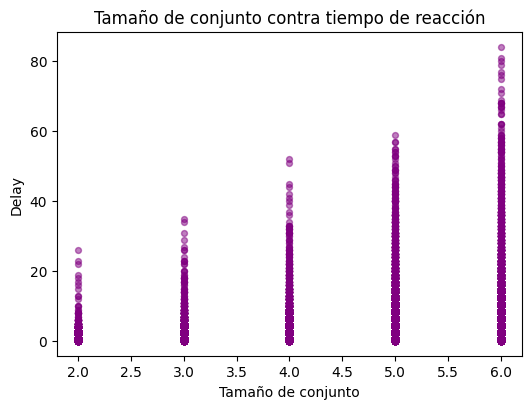

In [47]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(
    df["ns"],
    df["delay"],
    s=18,
    alpha=0.5,
    color='purple'
)
ax.set_xlabel("Tamaño de conjunto")
ax.set_ylabel("Delay")
ax.set_title("Tamaño de conjunto contra tiempo de reacción")
plt.show()

**Lectura**: Se observa mayor delay a mayor tamaño de conjunto. Que es consistente con el diseño experimental, ya que a mayor tamaño de estímulos tarda más en volver en aparecer el mismo estímulo.

¿Cómo afecta el tamaño de conjunto en la respuesta correcta?

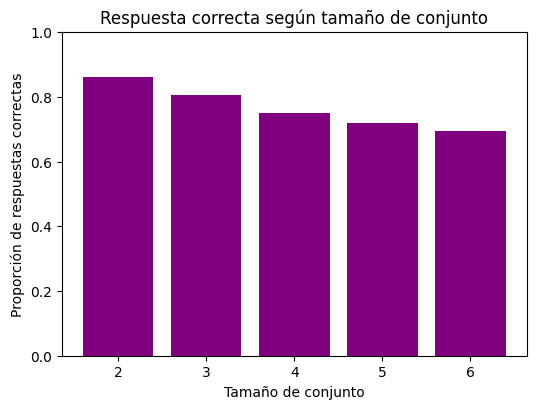

In [48]:
proporcion_correcta = df.groupby("ns")["cor"].mean()
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(
    proporcion_correcta.index,
    proporcion_correcta,
    color='purple'
)
ax.set_xlabel("Tamaño de conjunto")
ax.set_ylabel("Proporción de respuestas correctas")
ax.set_title("Respuesta correcta según tamaño de conjunto")
ax.set_ylim(0, 1)
plt.show()

**Lectura**: Se observa un leve patrón de menor proporción de respuestas correctas a mayor tamaño de conjunto. Que es consistente con el diseño experimental, ya que a mayor tamaño de estímulos se satura la memoria de trabajo.

¿Cómo afecta el grupo en la respuesta correcta?

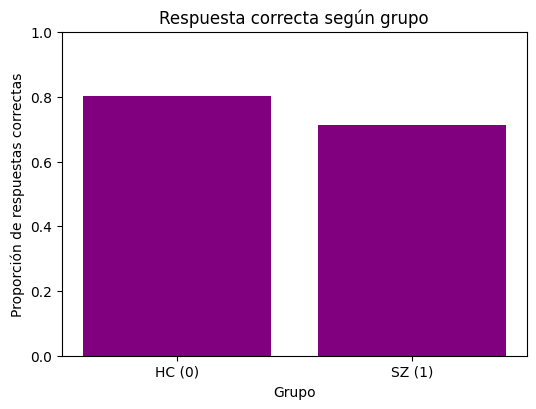

In [49]:
proporcion_correcta = df.groupby("condition (HC=0,SZ=1)")["cor"].mean()
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(
    proporcion_correcta.index,
    proporcion_correcta,
    color='purple'
)
ax.set_xlabel("Grupo")
ax.set_ylabel("Proporción de respuestas correctas")
ax.set_title("Respuesta correcta según grupo")
ax.set_xticks([0, 1])
ax.set_xticklabels(["HC (0)", "SZ (1)"])
ax.set_ylim(0, 1)
plt.show()

**Lectura**: Se ve una pequeña disminución de respuestas correctas en el grupo 'esquizofrenia' en comparación al grupo control.

¿Cómo afecta el grupo en el delay?

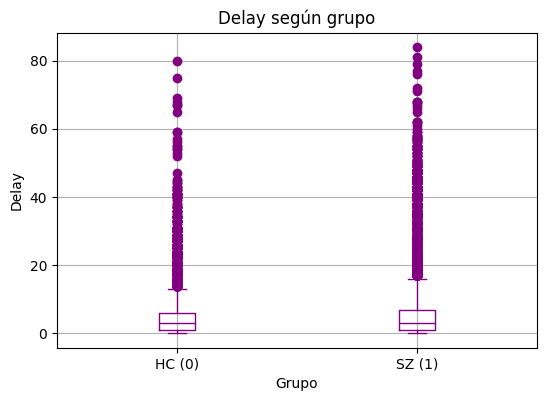

In [50]:
fig, ax = plt.subplots(figsize=(6, 4.2))
df.boxplot(
    column="delay",
    by="condition (HC=0,SZ=1)",
    ax=ax,
    boxprops=dict(color="purple"),
    medianprops=dict(color="purple"),
    whiskerprops=dict(color="purple"),
    capprops=dict(color="purple"),
    flierprops=dict(
        markeredgecolor="purple",
        markerfacecolor="purple")
)
ax.set_xlabel("Grupo")
ax.set_ylabel("Delay")
ax.set_title("Delay según grupo")
ax.set_xticks([1, 2])
ax.set_xticklabels(["HC (0)", "SZ (1)"])
plt.suptitle("")
plt.show()

**Lectura**: Se ve un leve aumento de delay en el grupo 'esquizofrenia' en comparación al grupo control. Sin embargo, ambos tienen una gran cantidad de datos atípicos. El bigote inferior se encuentra donde mismos, al igual que la media. Sin embargo el Q3 muestra mayor variabilidad en el grupo experimental que en el control.

**ANÁLISIS MULTIVARIADO**: Al menos una vista multivariada, e.g., matriz de correlación, matriz de dispersión, o el uso del color como tercera dimensión.

¿El delay de ve afectado por grupo y tamaño de conjunto?

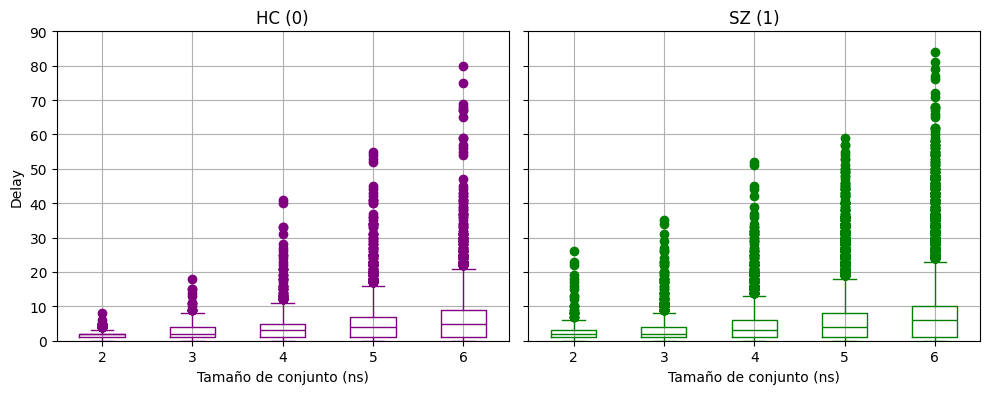

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
grupos = [0, 1]
nombres = ["HC (0)", "SZ (1)"]
colores = ["purple", "green"]
for ax, grupo, nombre, color in zip(axes, grupos, nombres, colores):
    datos = df[df["condition (HC=0,SZ=1)"] == grupo]
    datos.boxplot(
        column="delay",
        by="ns",
        ax=ax,
        boxprops=dict(color=color),
        medianprops=dict(color=color),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(
            markeredgecolor=color,
            markerfacecolor=color
        )
    )
    ax.set_title(nombre)
    ax.set_xlabel("Tamaño de conjunto (ns)")
    ax.set_ylabel("Delay")
    # mismo rango eje y para las dos gráficas
    ax.set_ylim(0, 90)
# ocultar eje y de la segunda gráfica
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelleft=False)
plt.suptitle("")
plt.tight_layout()
plt.show()

**Lectura**: Se observa mayor dispersión en el grupo experimental en comparación al control, independientemente del tamaño de conjunto, aunque mínima. A partir del tamaño de conjunto 3 se observa que el Q3 se expande más en el grupo 'esquizofrenia' que en el grupo control. Esto tiene sentido ya que el artículo concluye que la memoria de trabajo se ve afectada en la esquizofrenia, y a mayor cantidad de estímulos mayor saturación de la memoria de trabajo.

**LIMPIEZA DE DATOS**
Se vuelven a cargar los datos originales, porque en la exploración se modificó df. La limpieza se hace sobre una copia para poder comparar antes y después.

1. Primero se convierte el -1 a NaN en las cinco columnas donde se confirmó que es un código de ausencia:

In [52]:
df_inicial = pd.read_csv("/content/drive/MyDrive/INTRODUCCIÓN A LA CIENCIA DE DATOS/practicas/practica2/data/CollinsEtAl_2014_JoN.csv")
df_limpio = df_inicial.copy()
variable_objetivo = "condition (HC=0,SZ=1)"
columnas_ausencia = ["choice", "key", "cor", "rew", "rt"]
df_limpio[columnas_ausencia] = df_limpio[columnas_ausencia].replace(-1, np.nan)
pd.DataFrame({
    "antes": df_inicial.isna().sum(),
    "después": df_limpio.isna().sum(),
}).query("antes > 0 or después > 0")

,antes,después
choice,0,181
key,0,181
cor,0,181
rew,0,181
rt,0,181
delay,10544,10544


**Lectura:** Las cinco columnas pasan de 0 a 181 faltantes, el mismo número de registros con -1 que se encontró en la exploración. delay se mantiene en 10544, porque todavía no se ha tratado.

2. En las primeras filas, delay falta cuando pcor es 0, es decir, cuando todavía no hay un acierto previo para ese estímulo. Si esto se cumple siempre, el faltante no es un error de registro: no hay demora que medir.

In [53]:
pd.crosstab(df_limpio["delay"].isna(), df_limpio["pcor"] == 0,
            rownames=["delay faltante"], colnames=["pcor = 0"])

pcor = 0,False,True
delay faltante,,
False,36132,0
True,0,10544


**Lectura:** La relación es exacta: delay falta en los 10544 registros con pcor igual a 0, y en ningún otro. El faltante es estructural. Si no hay un acierto previo para el estímulo, no hay demora que medir.

Por tanto, los faltantes de delay no se imputan. No son datos perdidos, la demora no existe cuando no hay un acierto previo.

3. Las cinco columnas tienen 181 faltantes cada una. Antes de decidir, se verifica si corresponden a los mismos registros:

In [54]:
faltantes_respuesta = df_limpio[columnas_ausencia].isna()
print("Registros con al menos un faltante:", faltantes_respuesta.any(axis=1).sum())
print("Registros con los cinco faltantes: ", faltantes_respuesta.all(axis=1).sum())

Registros con al menos un faltante: 181
Registros con los cinco faltantes:  181


**Lectura:** Los 181 faltantes caen en los mismos registros: son ensayos completos sin respuesta, no fallas aisladas de una columna.

Se eliminan los 181 registros sin respuesta. No se imputan porque no hubo elección, no existe un valor que estimar. Iría contra la lógica del diseño experimental.

In [55]:
df_limpio = df_limpio.dropna(subset=columnas_ausencia)
print("Registros antes:  ", len(df_inicial))
print("Registros después:", len(df_limpio))

Registros antes:   46676
Registros después: 46495


4. Comparación del tiempo de reacción antes y después de eliminar los registros sin respuesta:

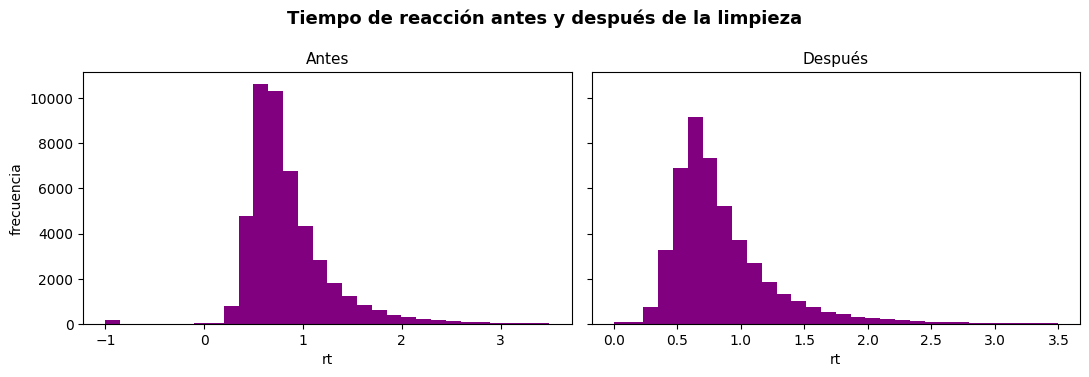

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, datos, titulo in zip(axes.ravel(), [df_inicial, df_limpio], ["Antes", "Después"]):
    ax.hist(datos["rt"], bins=30, color="purple")
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("rt")
axes[0].set_ylabel("frecuencia")
fig.suptitle("Tiempo de reacción antes y después de la limpieza",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura:** Antes de la limpieza aparece una barra aislada en -1, separada del resto de la distribución. Después desaparece y el eje empieza en 0. La distribución no cambia. Se puede observar distinta por el acomodo de los bins, pero es la misma distribución.

5. Se revisa que el conjunto limpio cumpla con lo decidido: sin códigos -1, faltantes solo en delay y sin duplicados exactos.

In [57]:
pd.Series({
    "registros": len(df_limpio),
    "códigos -1": (df_limpio[columnas_ausencia] == -1).sum().sum(),
    "faltantes fuera de delay": df_limpio.drop(columns="delay").isna().sum().sum(),
    "faltantes en delay": df_limpio["delay"].isna().sum(),
    "duplicados exactos": df_limpio.duplicated().sum(),
}).to_frame("resultado")

,resultado
registros,46495
códigos -1,0
faltantes fuera de delay,0
faltantes en delay,10481
duplicados exactos,0


*Registro de decisiones*

- `-1` en `choice`, `key`, `cor`, `rew` y `rt`: convertido a NaN.
- 181 ensayos sin respuesta: eliminados.
- `delay` faltante cuando `pcor` es 0: se conserva como NaN.

**EXTRACCIÓN DE CARACTERÍSTICAS**

1. Primero se revisa cuántos participantes hay en cada grupo.

In [58]:
df_limpio.groupby(variable_objetivo)["subno"].nunique()

,subno
"condition (HC=0,SZ=1)",
0,36
1,49


**Lectura:** Hay 85 participantes: 36 del grupo control y 49 del grupo con esquizofrenia.

2. Para cada participante se calculan la proporción de respuestas correctas y el tiempo de reacción promedio en cada tamaño de conjunto (2 a 6). Se toma el desempeño por tamaño de conjunto porque es la manipulación central del artículo para separar memoria de trabajo y aprendizaje por refuerzo.

    Esto genera 10 columnas nuevas, y a partir de aquí se trabaja con ellas en lugar de las originales. La mayoría de las columnas originales identifican al participante o describen el diseño del experimento (bloque, estímulo, imagen), y `cor` y `rt` quedan resumidas en las nuevas características.

In [60]:
caracteristicas = df_limpio.pivot_table(index="subno", columns="ns",
                                        values=["cor", "rt"], aggfunc="mean")
caracteristicas.columns = [f"{variable}_ns{ns}" for variable, ns in caracteristicas.columns]
caracteristicas[variable_objetivo] = df_limpio.groupby("subno")[variable_objetivo].first()
caracteristicas = caracteristicas.reset_index()
print("Forma:", caracteristicas.shape)
print("Faltantes:", caracteristicas.isna().sum().sum())
caracteristicas.head()

Forma: (85, 12)
Faltantes: 0


,subno,cor_ns2,cor_ns3,cor_ns4,cor_ns5,cor_ns6,rt_ns2,rt_ns3,rt_ns4,rt_ns5,rt_ns6,"condition (HC=0,SZ=1)"
0,3093,0.906250,0.916667,0.650000,0.733333,0.577778,0.637757,0.728058,0.766967,0.753846,0.807146,1
1,3960,0.925926,0.644444,0.666667,0.653846,0.644444,0.631387,0.739104,0.723319,0.860459,0.838441,1
2,8673,0.847222,0.851852,0.741935,0.762195,0.842593,0.594169,0.819676,0.760390,0.791600,0.808273,1
3,11430,0.847222,0.907407,0.632184,0.770833,0.825301,0.491955,0.625911,0.672967,0.668584,0.702440,1
4,11586,0.857143,0.805556,0.854167,0.641026,0.590643,0.736074,0.776209,0.779946,0.888979,1.050446,1


**Lectura:** La nueva tabla tiene 85 filas (una por participante) y 12 columnas: el identificador del participante, las 10 características creadas y la variable objetivo. No hay faltantes, así que todos los participantes completaron bloques de los cinco tamaños de conjunto.

3. Comparación del tiempo de reacción por tamaño de conjunto antes de la extracción (un valor por ensayo) y después (un promedio por participante)

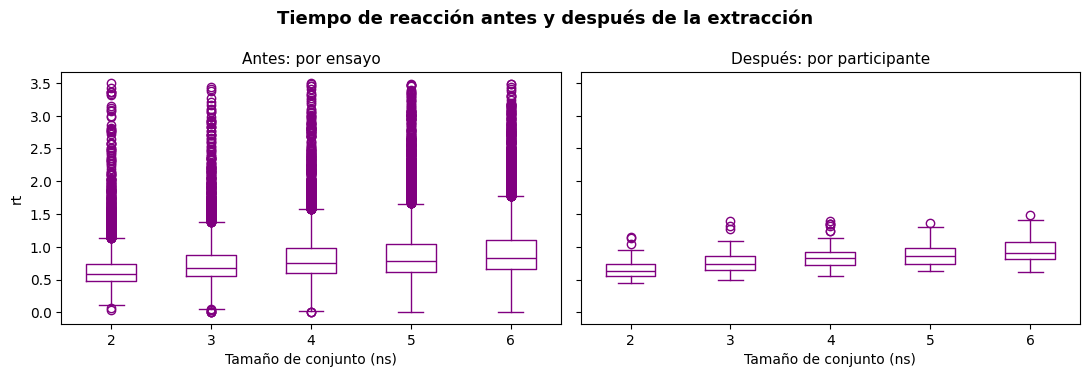

In [61]:
tamanos = range(2, 7)
antes = [df_limpio.loc[df_limpio["ns"] == ns, "rt"] for ns in tamanos]
despues = [caracteristicas[f"rt_ns{ns}"] for ns in tamanos]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

for ax, datos, titulo in zip(axes.ravel(), [antes, despues],
                             ["Antes: por ensayo", "Después: por participante"]):
    ax.boxplot(datos, tick_labels=list(tamanos),
               boxprops=dict(color="purple"),
               medianprops=dict(color="purple"),
               whiskerprops=dict(color="purple"),
               capprops=dict(color="purple"),
               flierprops=dict(markeredgecolor="purple"))
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("Tamaño de conjunto (ns)")

axes[0].set_ylabel("rt")
fig.suptitle("Tiempo de reacción antes y después de la extracción",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura.** A nivel ensayo, el tiempo de reacción tiene mucha dispersión y una gran cantidad de atípicos que llegan hasta 3.5 segundos. Al promediar por participante, la dispersión se reduce mucho: los valores quedan aproximadamente entre 0.5 y 1.5 segundos, con pocos atípicos. La tendencia se conserva en ambos niveles: la mediana sube conforme aumenta el tamaño de conjunto. Los atípicos que quedan después ya no son ensayos aislados, sino participantes que en promedio responden más lento.

¿El tiempo de reacción por tamaño de conjunto cambia según el grupo en el nuevo conjunto de datos?

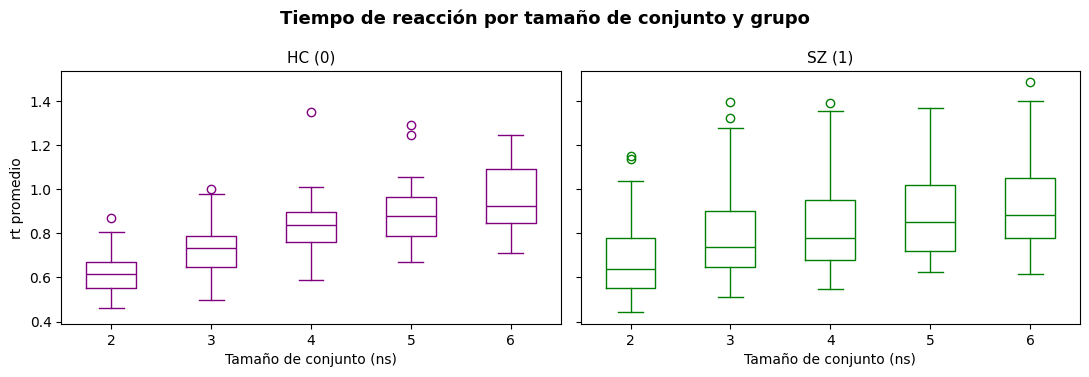

In [62]:
nombres = ["HC (0)", "SZ (1)"]
colores = ["purple", "green"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

for ax, grupo, nombre, color in zip(axes.ravel(), [0, 1], nombres, colores):
    datos = caracteristicas[caracteristicas[variable_objetivo] == grupo]
    ax.boxplot([datos[f"rt_ns{ns}"] for ns in tamanos], tick_labels=list(tamanos),
               boxprops=dict(color=color),
               medianprops=dict(color=color),
               whiskerprops=dict(color=color),
               capprops=dict(color=color),
               flierprops=dict(markeredgecolor=color))
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Tamaño de conjunto (ns)")

axes[0].set_ylabel("rt promedio")
fig.suptitle("Tiempo de reacción por tamaño de conjunto y grupo",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura.** En ambos grupos el tiempo de reacción promedio aumenta con el tamaño de conjunto. Las medianas son muy parecidas entre grupos, incluso en los tamaños 4 a 6 la del grupo SZ queda ligeramente por debajo de la del control. La diferencia está en la dispersión, las cajas del grupo SZ son más anchas y sus bigotes llegan más alto en todos los tamaños de conjunto, es decir, entre los participantes con esquizofrenia hay más variabilidad en la velocidad de respuesta.

¿La proporción de aciertos por tamaño de conjunto cambia según el grupo?

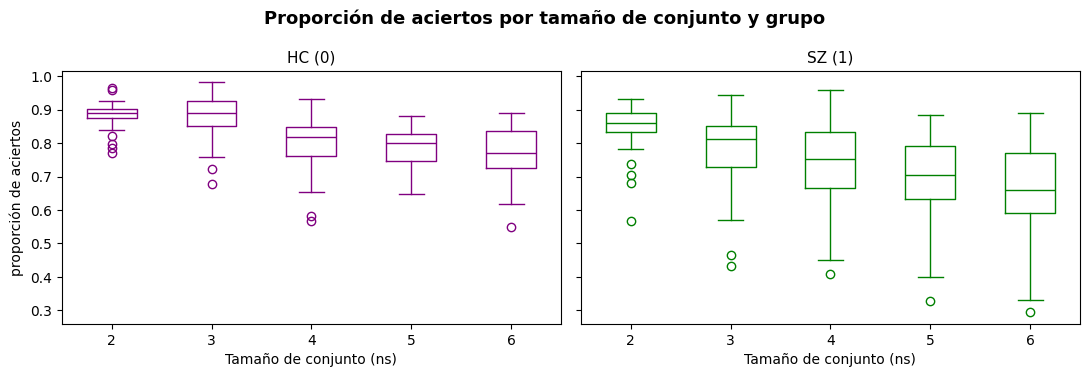

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

for ax, grupo, nombre, color in zip(axes.ravel(), [0, 1], nombres, colores):
    datos = caracteristicas[caracteristicas[variable_objetivo] == grupo]
    ax.boxplot([datos[f"cor_ns{ns}"] for ns in tamanos], tick_labels=list(tamanos),
               boxprops=dict(color=color),
               medianprops=dict(color=color),
               whiskerprops=dict(color=color),
               capprops=dict(color=color),
               flierprops=dict(markeredgecolor=color))
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Tamaño de conjunto (ns)")

axes[0].set_ylabel("proporción de aciertos")
fig.suptitle("Proporción de aciertos por tamaño de conjunto y grupo",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura:** En ambos grupos la proporción de aciertos baja conforme aumenta el tamaño de conjunto, pero en el grupo SZ la caída es más pronunciada. El grupo SZ también muestra más dispersión. Esto es consistente con el artículo, la diferencia entre grupos crece cuando la carga de memoria de trabajo es mayor.

**SELECCIÓN DE CARACTERÍSTICAS**

1. Las 10 características miden lo mismo (aciertos y tiempo de reacción) en distintos tamaños de conjunto, así que es posible que algunas sean redundantes. Se aplica un filtro por correlación: si dos características tienen una correlación de Pearson mayor a 0.9 en valor absoluto, se conserva solo una. Se elige un filtro porque en esta práctica no se entrena ningún modelo, y otros métodos de selección dependen del desempeño de uno. Además, el filtro no usa la variable objetivo.

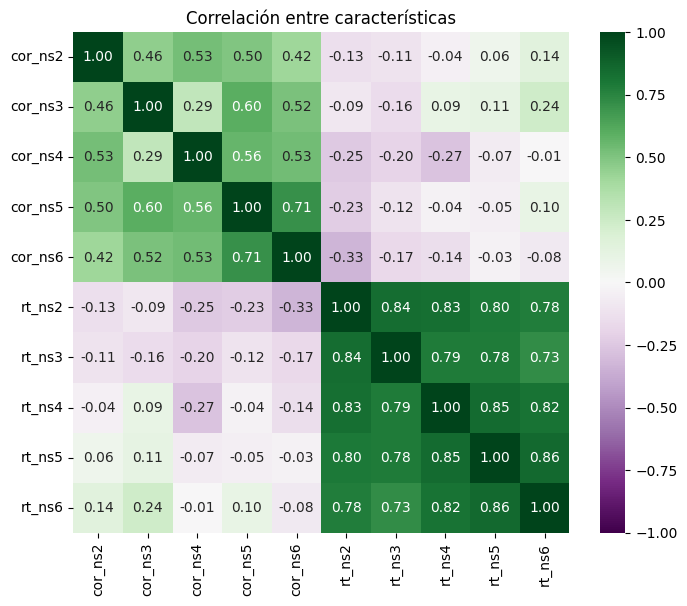

In [64]:
variables_caracteristicas = [columna for columna in caracteristicas.columns
                             if columna not in ["subno", variable_objetivo]]
correlacion = caracteristicas[variables_caracteristicas].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="PRGn",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre características")
plt.show()

**Lectura:** Ninguna pareja supera el umbral de 0.9. Los tiempos de reacción están muy correlacionados entre sí, los aciertos de forma moderada. Entre aciertos y tiempos casi no hay relación. Con el criterio declarado, se conservan las 10 características.

2. Considero que lo mejor sería usar un método que evalúe las características con un modelo y partir de ahí. Sin embargo, con fines de la práctica, se reduce el umbral a 0.75 y se eliminan las características que lo superan.

In [65]:
superior = correlacion.abs().where(np.triu(np.ones(correlacion.shape, dtype=bool), k=1))
eliminadas = [columna for columna in superior.columns if (superior[columna] > 0.75).any()]
variables_seleccionadas = [columna for columna in variables_caracteristicas
                           if columna not in eliminadas]

print("Eliminadas:  ", eliminadas)
print("Conservadas: ", variables_seleccionadas)

Eliminadas:   ['rt_ns3', 'rt_ns4', 'rt_ns5', 'rt_ns6']
Conservadas:  ['cor_ns2', 'cor_ns3', 'cor_ns4', 'cor_ns5', 'cor_ns6', 'rt_ns2']


**Lectura:** Se eliminan los tiempos de reacción de los tamaños 3 a 6 y se conserva `rt_ns2`, que queda como representante del bloque de tiempos. Los cinco aciertos se mantienen porque ninguna pareja supera 0.75. El conjunto pasa de 10 a 6 características.

Comparación de la matriz de correlación antes y después de la selección:

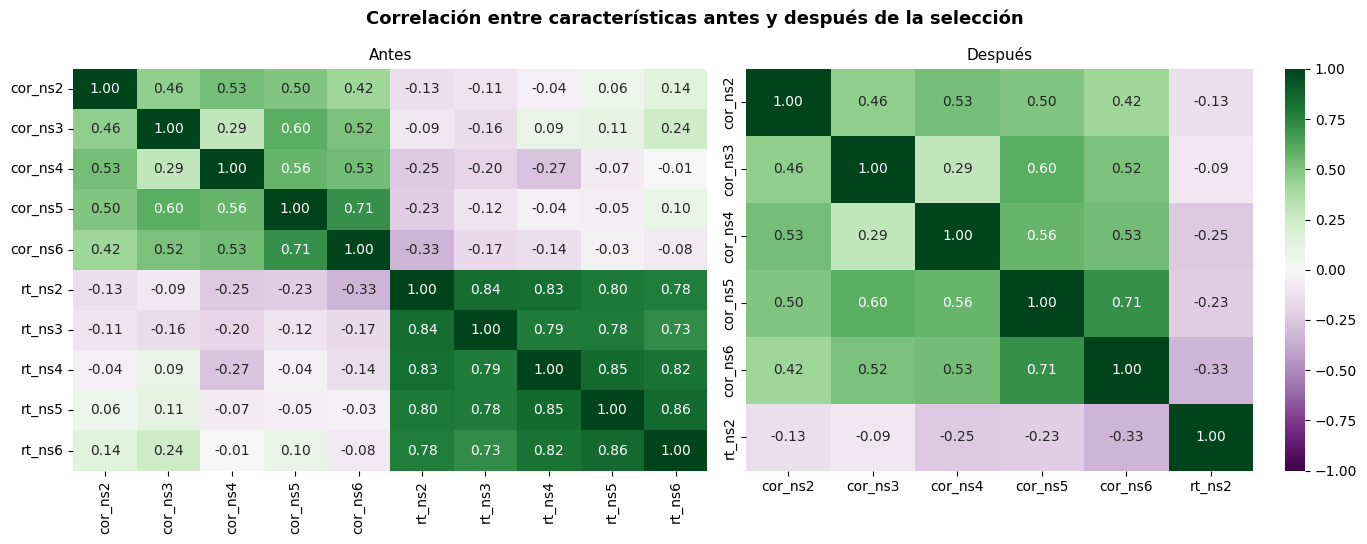

In [66]:
matrices = [correlacion, caracteristicas[variables_seleccionadas].corr()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, matriz, titulo, barra in zip(axes.ravel(), matrices, ["Antes", "Después"], [False, True]):
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="PRGn",
                vmin=-1, vmax=1, cbar=barra, ax=ax)
    ax.set_title(titulo, fontsize=11)

fig.suptitle("Correlación entre características antes y después de la selección",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura:** Después de la selección desaparece el bloque de tiempos de reacción altamente correlacionados. La correlación más alta que queda es 0.71 (`cor_ns5` con `cor_ns6`), y `rt_ns2` tiene una relación débil y negativa con los aciertos (de -0.09 a -0.33). El tiempo de reacción queda representado por una sola característica, y los aciertos conservan sus cinco tamaños de conjunto.

**PARTICIÓN**

1. Se separan entrenamiento (80 %) y prueba (20 %) de forma estratificada, para conservar la proporción de grupos en ambos conjuntos.

In [67]:
X = caracteristicas[variables_seleccionadas]
y = caracteristicas[variable_objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Entrenamiento:", y_train.value_counts().sort_index().to_dict())
print("Prueba:       ", y_test.value_counts().sort_index().to_dict())

Entrenamiento: {0: 29, 1: 39}
Prueba:        {0: 7, 1: 10}


**Lectura:** Entrenamiento queda con 68 participantes (29 del grupo control y 39 del grupo con esquizofrenia) y prueba con 17 (7 y 10).

**REDUCCIÓN DE DIMENSIONALIDAD**

1. Se aplica PCA sobre las 6 características seleccionadas. Antes se estandarizan, porque los aciertos son proporciones y el tiempo de reacción está en segundos; sin estandarizar, la variable con mayor varianza dominaría los componentes. El escalador y PCA se ajustan solo con entrenamiento.

Varianza por componente: [0.535 0.177 0.095 0.092 0.054 0.047]


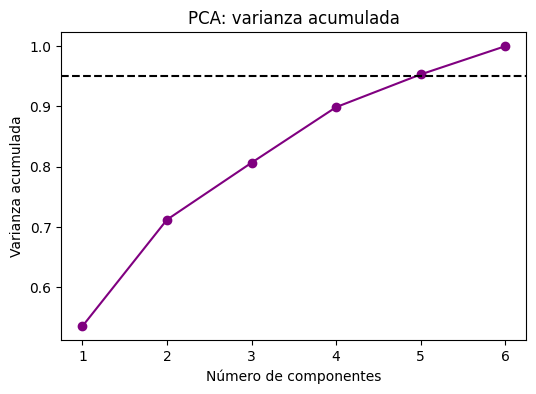

In [68]:
escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)

pca_completo = PCA().fit(X_train_escalado)
acumulada = np.cumsum(pca_completo.explained_variance_ratio_)
print("Varianza por componente:", pca_completo.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(acumulada) + 1), acumulada, marker="o", color="purple")
ax.axhline(0.95, color="black", linestyle="--")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza acumulada")
ax.set_title("PCA: varianza acumulada")
plt.show()

**Lectura:** El primer componente captura el 53.5 % de la varianza y el segundo el 17.7 %, así que entre las dos suman 71.2 %. A partir del tercero, cada componente aporta menos del 10 %. Para llegar al 95 % se necesitan 5 de los 6 componentes (95.3 %), por lo que la reducción posible es pequeña: tras la selección, las características comparten poca información redundante.

**Decisión:** La técnica se aplicó, pero conservar el 95 % de la varianza requiere 5 componentes de 6 características. La reducción sería mínima y los componentes perderían la interpretación directa que tienen las características originales. Por eso se continúa con las 6 características seleccionadas.

**AUMENTO DE DATOS**

1. En entrenamiento hay 29 participantes del grupo control y 39 del grupo con esquizofrenia. Se aplica SMOTE para igualar los grupos generando participantes sintéticos del grupo control.

    **Criterio:** Los sintéticos se consideran si sus medianas quedan cerca de las del grupo control original, y no cerca de las del grupo con esquizofrenia.

In [69]:
smote = SMOTE(random_state=42)
X_smote_escalado, y_smote = smote.fit_resample(X_train_escalado, y_train)
X_smote = pd.DataFrame(escalador.inverse_transform(X_smote_escalado),
                       columns=variables_seleccionadas)

print("Antes: ", y_train.value_counts().sort_index().to_dict())
print("Después:", y_smote.value_counts().sort_index().to_dict())

Antes:  {0: 29, 1: 39}
Después: {0: 39, 1: 39}


2. Se comparan las medianas de los participantes sintéticos con las del grupo control y las del grupo con esquizofrenia originales.

In [70]:
sinteticos = X_smote.iloc[len(X_train):]

pd.DataFrame({
    "HC original": X_train[y_train == 0].median(),
    "sintéticos": sinteticos.median(),
    "SZ original": X_train[y_train == 1].median(),
}).round(3)

,HC original,sintéticos,SZ original
cor_ns2,0.903,0.902,0.861
cor_ns3,0.889,0.898,0.806
cor_ns4,0.812,0.822,0.745
cor_ns5,0.800,0.784,0.704
cor_ns6,0.760,0.760,0.704
rt_ns2,0.627,0.649,0.637


**Lectura:** En los cinco aciertos, las medianas de los sintéticos quedan cerca del grupo control y lejos del grupo con esquizofrenia. En `rt_ns2` los sintéticos quedan un poco por encima de ambos grupos, pero la diferencia es pequeña y en esa característica los dos grupos casi no se distinguen. Se cumple el criterio: los sintéticos se parecen al grupo control.

3. Antes y después de SMOTE: se grafica `cor_ns6`, donde más se separan los grupos, contra `rt_ns2`, el único tiempo de reacción que se conservó.

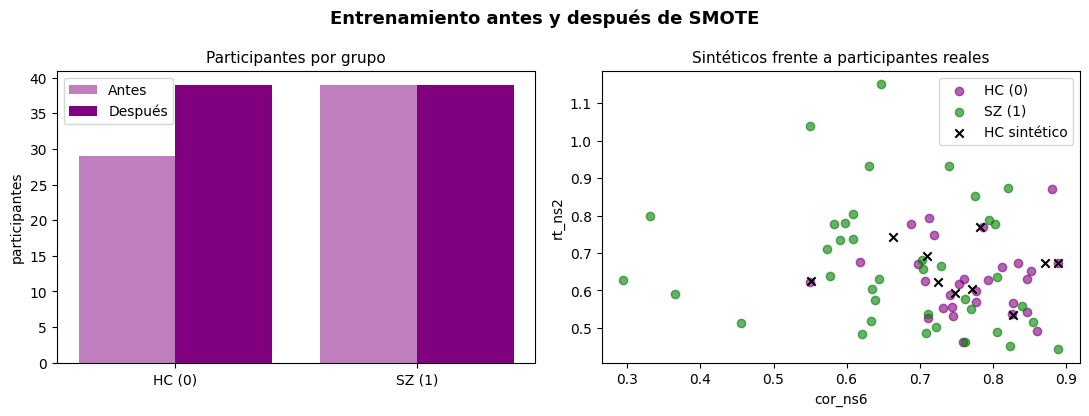

In [71]:
conteo_antes = y_train.value_counts().sort_index()
conteo_despues = y_smote.value_counts().sort_index()
posiciones = np.arange(2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(posiciones - 0.2, conteo_antes, width=0.4, color="purple", alpha=0.5, label="Antes")
axes[0].bar(posiciones + 0.2, conteo_despues, width=0.4, color="purple", label="Después")
axes[0].set_xticks(posiciones)
axes[0].set_xticklabels(nombres)
axes[0].set_ylabel("participantes")
axes[0].set_title("Participantes por grupo", fontsize=11)
axes[0].legend()

for grupo, nombre, color in zip([0, 1], nombres, colores):
    datos = X_train[y_train == grupo]
    axes[1].scatter(datos["cor_ns6"], datos["rt_ns2"], color=color, alpha=0.6, label=nombre)
axes[1].scatter(sinteticos["cor_ns6"], sinteticos["rt_ns2"], color="black", marker="x",
                label="HC sintético")
axes[1].set_xlabel("cor_ns6")
axes[1].set_ylabel("rt_ns2")
axes[1].set_title("Sintéticos frente a participantes reales", fontsize=11)
axes[1].legend()

fig.suptitle("Entrenamiento antes y después de SMOTE",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura:** El grupo control pasa de 29 a 39 participantes y el grupo con esquizofrenia se mantiene en 39. Los 10 sintéticos caen dentro de la nube del grupo control y ninguno aparece en la zona de aciertos bajos, que solo ocupa el grupo con esquizofrenia. Algunos quedan casi encima de un participante real, porque SMOTE los generó muy cerca de uno de los dos puntos que interpola. También se ve que, en este par de características, los grupos se traslapan bastante.

**CONCLUSIÓN**

Se aplicaron cinco técnicas de preprocesamiento al conjunto de Collins et al. (2014). En la limpieza, los `-1` se convirtieron a NaN y se eliminaron los 181 ensayos sin respuesta; los faltantes de `delay` se conservaron porque son estructurales (no hay demora sin un acierto previo). En la extracción, los ensayos se resumieron en 10 características por participante (aciertos y tiempo de reacción por tamaño de conjunto), lo que dejó 85 filas con la misma unidad que la variable objetivo. La selección por correlación eliminó cuatro tiempos de reacción redundantes y dejó 6 características. PCA mostró que se necesitan 5 componentes para conservar el 95 % de la varianza, por lo que se mantuvieron las características originales. Por último, SMOTE igualó los grupos en entrenamiento con 10 participantes sintéticos del grupo control, similares a los reales.

**Declaración de uso de IA**

Este notebook fue elaborado con apoyo de Claude (Anthropic) para resolver dudas sobre Python, preprocesamiento de datos y visualización. La interpretación de los resultados y la revisión final son responsabilidad del autor.